In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# define file paths 
RAW_TWEET_PATH = "../data/raw/raw_tweets.csv"
TWEET_PATH = "../data/processed/clean_tweets.csv"
MODEL_TABLE_PATH = "../data/results/modelling_table.csv"
MNLG_TABLE_PATH = "../data/results/mn_logreg_evaluation.csv"
RF_TABLE_PATH = "../data/results/rf_evaluation.csv"
GB_TABLE_PATH = "../data/results/gb_evaluation.csv"

# load datasets 
raw_df = pd.read_csv(RAW_TWEET_PATH)
model_df = pd.read_csv(MODEL_TABLE_PATH, index_col="date")  # main modelling table with sentiment and returns
mnlg_df = pd.read_csv(MNLG_TABLE_PATH)  # multinomial logistic regression evaluation metrics
rf_df = pd.read_csv(RF_TABLE_PATH)  # random forest evaluation metrics
gb_df = pd.read_csv(GB_TABLE_PATH)  # gradient boost evaluation metrics
tweet_df = pd.read_csv(TWEET_PATH) # scored tweets

## Exploratory Data Analysis 
This notebook will explore the modelling table of financial and social data to explore its relationships and patterns

### Cleaning QA

In [28]:
sample_idx = raw_df.sample(5).index
with pd.option_context('display.max_colwidth', None):
    display(pd.concat([raw_df.loc[sample_idx, ["text"]], tweet_df.loc[sample_idx, ["text"]]]))

,text
502119,Major world indices:\n$SPX: 3037.10\n$FTSE: 6124.50\n$DAX: 12016.75\n$Nikkei: 22130.00\nMore at https://t.co/Jbuj8gzfWH
462142,"RT @BeastModeTrades: $SPY -3 319.5 Key support, hold &amp; this retests 321.5, 322.5+ \n$AMZN +3 2520 Key support, hold &amp; this can test 2530,…"
761107,RT @ImKeithDavid: I’m sure @Disney would agree that it’s incredibly important to prioritize the safety of their staff and audiences above a…
338823,RT @JDean01647547: @marklevinshow #YOUTUBE $FB $GOOG $TWTR #FACEBOOK CAUGHT RED-HANDED... \n #FACTcheckers are being Fact-checked by the #F…
343199,RT @wallstreetelix5: $spy $spx $es $aapl $goog $tdla. We will be over 3100 Monday
502119,major world indices $spx 3037 10 $ftse 6124 50 $dax 12016 75 $nikkei 22130 00 more at
462142,rt $spy 3 319 5 key support hold amp this retests 321 5 322 5 $amzn 3 2520 key support hold amp this can test 2530
761107,rt i m sure would agree that it s incredibly important to prioritize the safety of their staff and audiences above a
338823,rt youtube $fb $goog $twtr facebook caught red handed factcheckers are being fact checked by the f
343199,rt $spy $spx $es $aapl $goog $tdla we will be over 3100 monday


### Sentiment Scoring QA
Select 100 random tweets containing the word "grow" and 100 containing "fall" and compute average sentiment scores in order to assess the quality of scores 

In [29]:
test_df = tweet_df.sample(5)
with pd.option_context('display.max_colwidth', None):
    display(test_df.head())

,timestamp,text,fb_score
66738,2020-04-15 16:59:43+00:00,socialstocks facebook ad budgets slump twitter shares more with advertisers $googl $goog $fb $zm $twtr $pins,0.017395
745088,2020-07-02 04:49:43+00:00,rt to understand what has happened to the u s stock market you need to first accept that $msft $aapl $googl $amzn t,0.014764
31432,2020-04-12 03:24:49+00:00,rt $spx high of 2810 last week is at a level that has been a pivot point for a lot of moves in the past also happens to be 50% re,0.076323
274004,2020-05-05 20:19:34+00:00,i was only at wdw in q2 but yep it felt busy so not surprised that $dis was trending upwards,0.360521
225871,2020-04-28 15:42:46+00:00,war bullish $spx es_f,-0.004272


In [30]:
pos_df = tweet_df.loc[tweet_df["text"].str.contains("rise", na=False)]

test_df = pos_df.sample(100)
display (test_df.head())

mean_score = round(test_df["fb_score"].mean(), 6)

print(f"Arithmetic Mean finBERT score of results: {mean_score}")

,timestamp,text,fb_score
77610,2020-04-16 22:55:40+00:00,the next 45 days are the most critical period ...,0.068549
511980,2020-06-14 03:18:58+00:00,zacks icahn enterprises lp $iep given average ...,0.853392
549479,2020-06-17 12:17:03+00:00,businessnews marketnews news stocks amd stock ...,0.834714
608095,2020-06-22 01:50:01+00:00,$lpcn we have detected a noticeable rise in th...,0.322782
478921,2020-06-10 12:20:43+00:00,gold rises as investors await fomc economic fo...,0.419797


Arithmetic Mean finBERT score of results: 0.242101


In [31]:
neg_df = tweet_df[tweet_df["text"].str.contains("fall", na=False)]

test_df = neg_df.sample(100)
display(test_df.head())

mean_score = round(test_df["fb_score"].mean(), 6)

print(f"Arithmetic Mean finBERT score of results: {mean_score}")

,timestamp,text,fb_score
900490,2020-07-15 14:10:00+00:00,in focus get ready for the fall markets retest...,0.070505
107358,2020-04-18 23:07:36+00:00,rt 1 s amp p500 rebound recovery newbull miles...,0.175290
433885,2020-06-07 19:36:38+00:00,rt usd falling in value spx500 going parabolic...,-0.868468
195495,2020-04-25 14:25:11+00:00,$xom $cvx $cop $uso scary visceral unprecedent...,-0.651188
38781,2020-04-13 15:00:37+00:00,rt unique analysis by in his premium letter th...,-0.941245


Arithmetic Mean finBERT score of results: -0.433052


### Modelling Table Visualizations

#### Time Series of Sentiment Scores

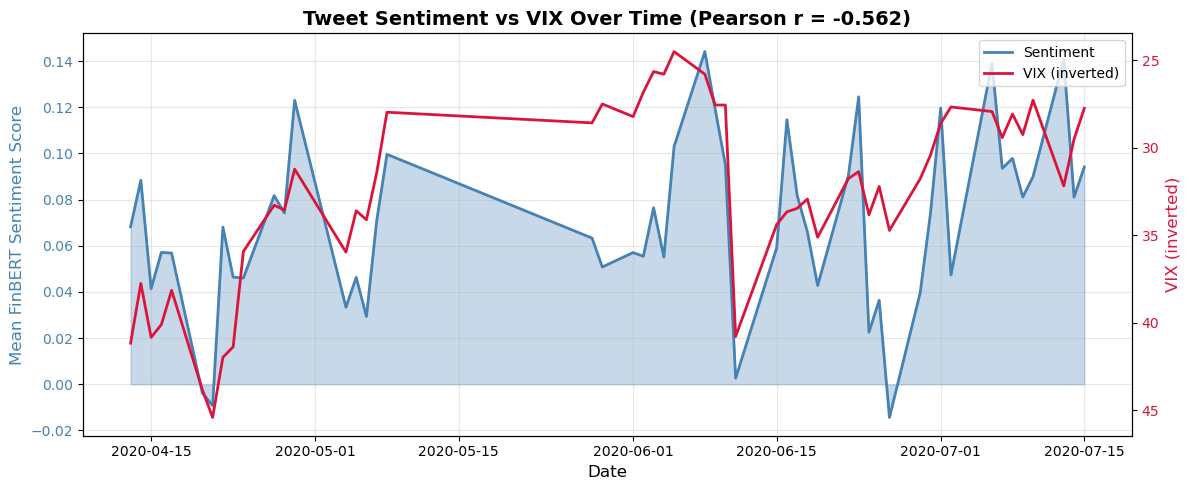

In [32]:
# convert date index to datetime for proper plotting
model_df.index = pd.to_datetime(model_df.index)

# calculate Pearson correlation between sentiment and VIX
pearson_corr = model_df['mean_fb_score'].corr(model_df['VIX'])

# create time series plot with dual y-axes
fig, ax1 = plt.subplots(figsize=(12, 5))

# plot sentiment on left axis
ax1.plot(model_df.index, model_df['mean_fb_score'], linewidth=2, color='steelblue', label='Sentiment')
ax1.fill_between(model_df.index, model_df['mean_fb_score'], alpha=0.3, color='steelblue')
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Mean FinBERT Sentiment Score', fontsize=12, color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# plot VIX on right axis (inverted)
ax2 = ax1.twinx()
ax2.plot(model_df.index, model_df['VIX'], linewidth=2, color='crimson', label='VIX (inverted)')
ax2.set_ylabel('VIX (inverted)', fontsize=12, color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')
ax2.invert_yaxis()

# add title with Pearson correlation and combined legend
ax1.set_title(f'Tweet Sentiment vs VIX Over Time (Pearson r = {pearson_corr:.3f})', fontsize=14, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
ax1.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

### Evaluation Table Visualizations

#### Accuracy Across Sectors

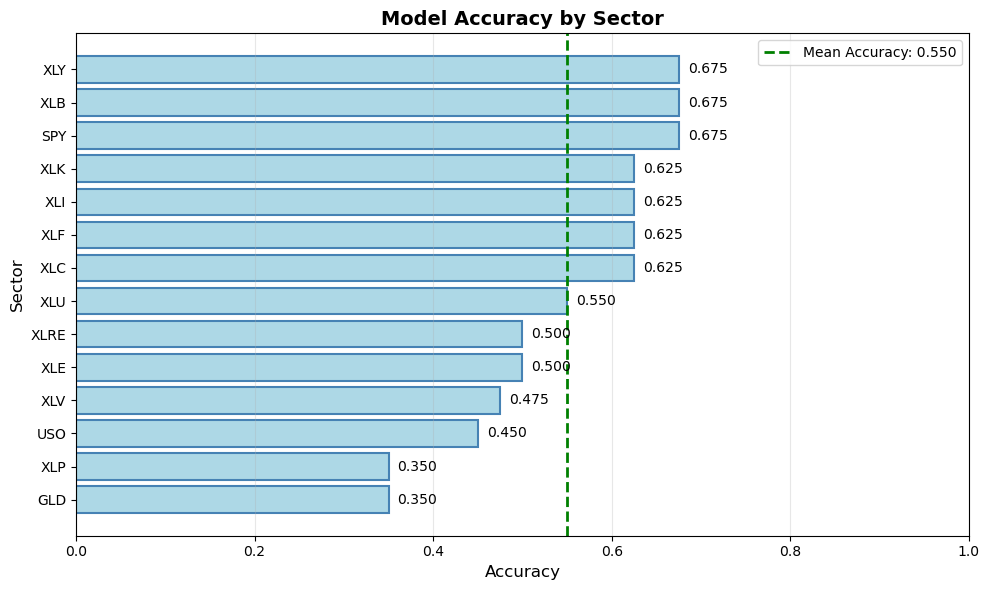

In [34]:
# sort sectors by accuracy 
sorted_df = mnlg_df.sort_values('accuracy_mean', ascending=True)

# create horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(sorted_df['ticker'], sorted_df['accuracy_mean'], color='lightblue', edgecolor='steelblue', linewidth=1.5)

# add accuracy value labels to each bar
for i, (ticker, accuracy) in enumerate(zip(sorted_df['ticker'], sorted_df['accuracy_mean'])):
    ax.text(accuracy + 0.01, i, f'{accuracy:.3f}', va='center', fontsize=10)

# add vertical line showing mean accuracy
mean_accuracy = mnlg_df['accuracy_mean'].mean()
ax.axvline(mean_accuracy, color='green', linestyle='--', linewidth=2, label=f'Mean Accuracy: {mean_accuracy:.3f}')

# format axes and add labels
ax.set_xlabel('Accuracy', fontsize=12)
ax.set_ylabel('Sector', fontsize=12)
ax.set_title('Model Accuracy by Sector', fontsize=14, fontweight='bold')
ax.set_xlim(0, 1)
ax.legend()
ax.grid(True, alpha=0.3, axis='x')

fig.tight_layout()
plt.show()

#### Confusion Matrices by Sector

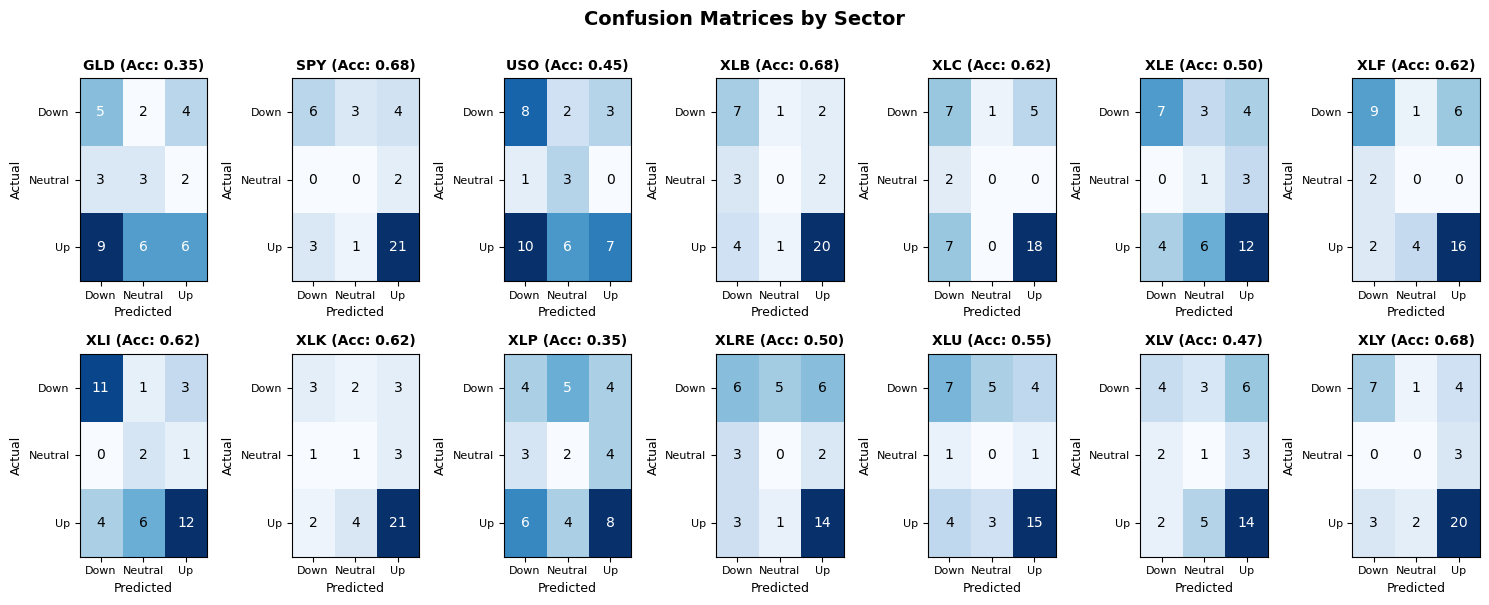

In [35]:
# extract confusion matrix columns and define class labels
cm_cols = [col for col in mnlg_df.columns if col.startswith('cm_')]
class_labels = ['Down', 'Neutral', 'Up']

# create grid of subplots 
fig, axes = plt.subplots(2, 7, figsize=(15, 6))
axes = axes.flatten()

# generate a confusion matrix heatmap for each sector
for idx, row in mnlg_df.iterrows():
    ax = axes[idx]
    
    # put the confusion matrix values into a 3x3 grid
    cm = np.array([row[col] for col in cm_cols]).reshape(3, 3)
    
    # create heatmap with blue colors
    im = ax.imshow(cm, cmap='Blues', aspect='auto')
    
    # set axis ticks and labels
    ax.set_xticks(np.arange(3))
    ax.set_yticks(np.arange(3))
    ax.set_xticklabels(class_labels, fontsize=8)
    ax.set_yticklabels(class_labels, fontsize=8)
    ax.set_ylabel('Actual', fontsize=9)
    ax.set_xlabel('Predicted', fontsize=9)
    
    # add count annotations to each cell
    for i in range(3):
        for j in range(3):
            text = ax.text(j, i, int(cm[i, j]), ha="center", va="center", 
                          color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=10)
    
    # add sector name and accuracy to subplot title
    ax.set_title(f'{row["ticker"]} (Acc: {row["accuracy_mean"]:.2f})', fontsize=10, fontweight='bold')

plt.suptitle('Confusion Matrices by Sector', fontsize=14, fontweight='bold', y=1.00)
fig.tight_layout()
plt.show()

### Random Forest Evaluation

#### Confusion Matrices by Sector

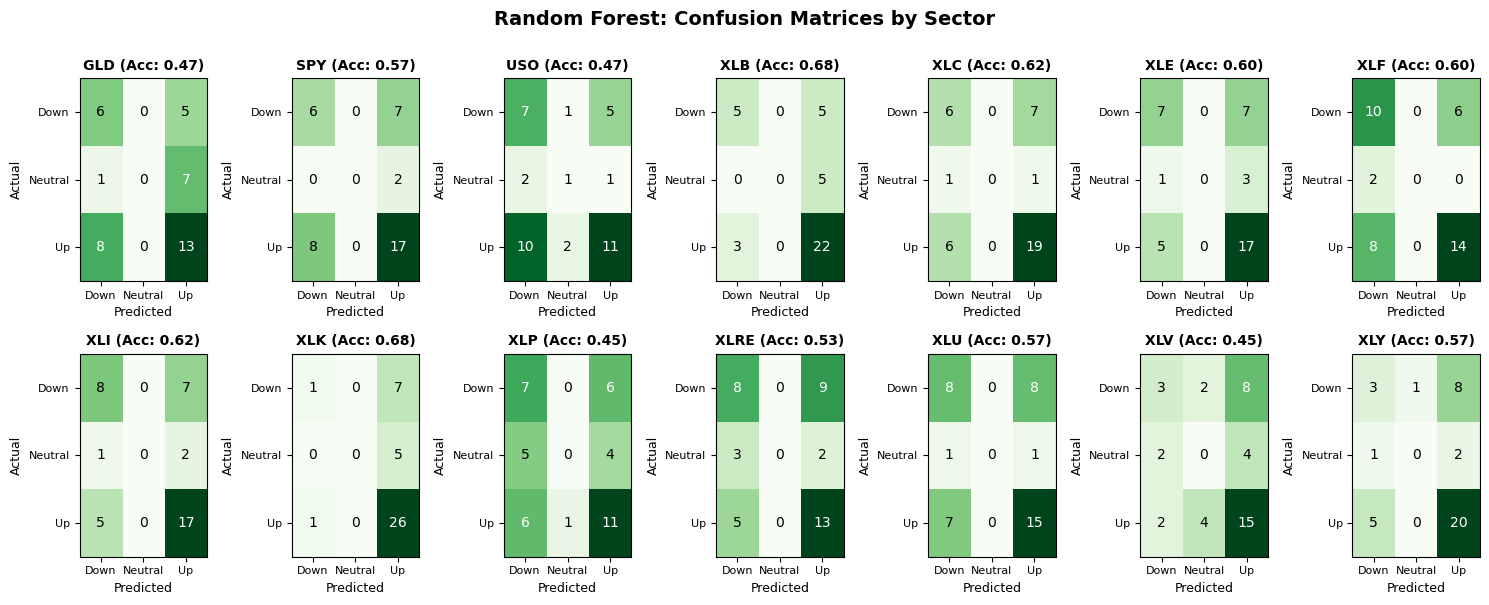

In [36]:
# extract confusion matrix columns and define class labels
cm_cols = [col for col in rf_df.columns if col.startswith('cm_')]
class_labels = ['Down', 'Neutral', 'Up']

# create grid of subplots 
fig, axes = plt.subplots(2, 7, figsize=(15, 6))
axes = axes.flatten()

# generate a confusion matrix heatmap for each sector
for idx, row in rf_df.iterrows():
    ax = axes[idx]
    
    # put the confusion matrix values into a 3x3 grid
    cm = np.array([row[col] for col in cm_cols]).reshape(3, 3)
    
    # create heatmap with green colors to differentiate from logistic regression
    im = ax.imshow(cm, cmap='Greens', aspect='auto')
    
    # set axis ticks and labels
    ax.set_xticks(np.arange(3))
    ax.set_yticks(np.arange(3))
    ax.set_xticklabels(class_labels, fontsize=8)
    ax.set_yticklabels(class_labels, fontsize=8)
    ax.set_ylabel('Actual', fontsize=9)
    ax.set_xlabel('Predicted', fontsize=9)
    
    # add count annotations to each cell
    for i in range(3):
        for j in range(3):
            text = ax.text(j, i, int(cm[i, j]), ha="center", va="center", 
                          color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=10)
    
    # add sector name and accuracy to subplot title
    ax.set_title(f'{row["ticker"]} (Acc: {row["accuracy_mean"]:.2f})', fontsize=10, fontweight='bold')

plt.suptitle('Random Forest: Confusion Matrices by Sector', fontsize=14, fontweight='bold', y=1.00)
fig.tight_layout()
plt.show()

### Gradient Boost Evaluation

#### Confusion Matrices by Sector

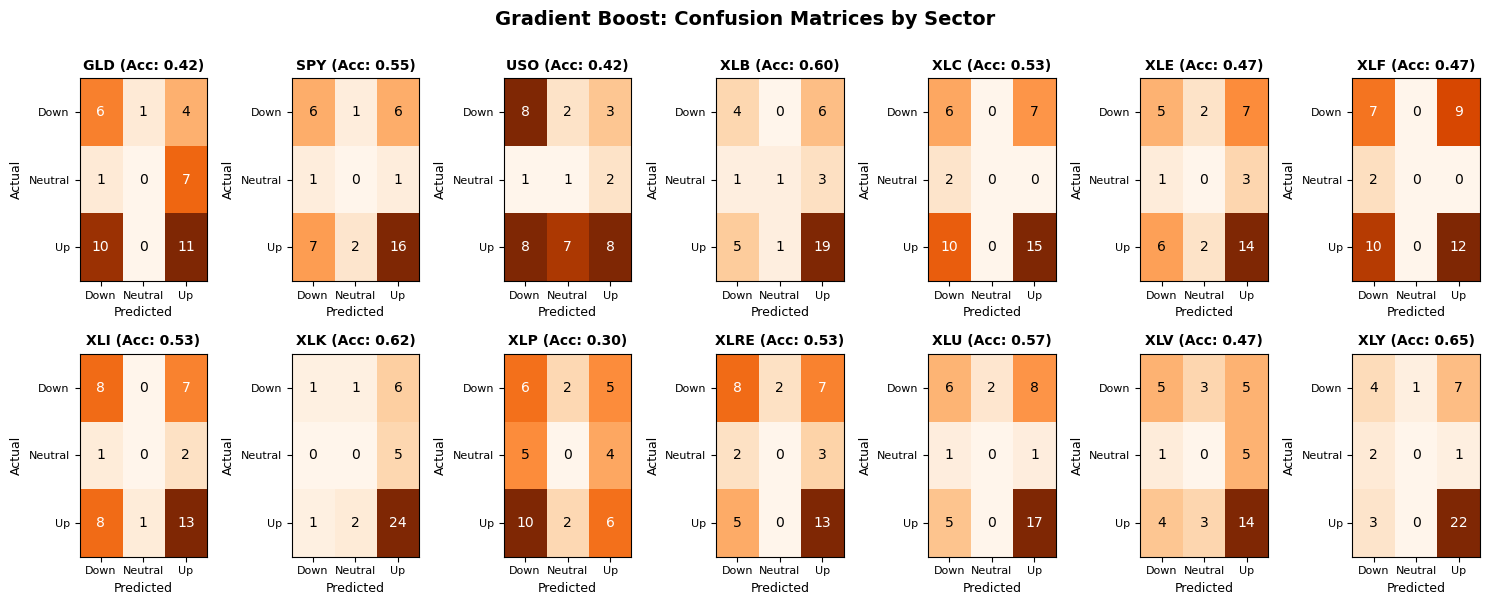

In [37]:
# extract confusion matrix columns and define class labels
cm_cols = [col for col in gb_df.columns if col.startswith('cm_')]
class_labels = ['Down', 'Neutral', 'Up']

# create grid of subplots 
fig, axes = plt.subplots(2, 7, figsize=(15, 6))
axes = axes.flatten()

# generate a confusion matrix heatmap for each sector
for idx, row in gb_df.iterrows():
    ax = axes[idx]
    
    # put the confusion matrix values into a 3x3 grid
    cm = np.array([row[col] for col in cm_cols]).reshape(3, 3)
    
    # create heatmap with orange colors to differentiate from other models
    im = ax.imshow(cm, cmap='Oranges', aspect='auto')
    
    # set axis ticks and labels
    ax.set_xticks(np.arange(3))
    ax.set_yticks(np.arange(3))
    ax.set_xticklabels(class_labels, fontsize=8)
    ax.set_yticklabels(class_labels, fontsize=8)
    ax.set_ylabel('Actual', fontsize=9)
    ax.set_xlabel('Predicted', fontsize=9)
    
    # add count annotations to each cell
    for i in range(3):
        for j in range(3):
            text = ax.text(j, i, int(cm[i, j]), ha="center", va="center", 
                          color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=10)
    
    # add sector name and accuracy to subplot title
    ax.set_title(f'{row["ticker"]} (Acc: {row["accuracy_mean"]:.2f})', fontsize=10, fontweight='bold')

plt.suptitle('Gradient Boost: Confusion Matrices by Sector', fontsize=14, fontweight='bold', y=1.00)
fig.tight_layout()
plt.show()